# Hybrid Code Generation Performance Analysis

Analysis of DeepSeek + Claude hybrid code generation execution metrics.

**Data Source**: `beast_mode_hybrid_execution.log`  
**Execution Mode**: Hybrid (DeepSeek generates → Claude reviews → Iterative refinement)  
**Parallel Agents**: 4

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

# Read log file
log_file = Path('../beast_mode_hybrid_execution.log')
log_data = log_file.read_text()

print(f"Log file size: {len(log_data):,} bytes")

Log file size: 59,927 bytes


## Task Completion Timeline

In [2]:
# Parse completed tasks with timestamps
completion_pattern = r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}),\d+ - __main__ - INFO - ✅ (agent_\d+) completed: ([^(]+) \((\d+) iterations, (.+)\)'

completions = []
for match in re.finditer(completion_pattern, log_data):
    timestamp = datetime.strptime(match.group(1), '%Y-%m-%d %H:%M:%S')
    agent = match.group(2)
    task = match.group(3).strip()
    iterations = int(match.group(4))
    status = match.group(5)
    
    completions.append({
        'timestamp': timestamp,
        'agent': agent,
        'task': task,
        'iterations': iterations,
        'status': status
    })

df = pd.DataFrame(completions)

if not df.empty:
    # Calculate time deltas
    df['time_from_start'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds() / 60
    df['task_duration'] = df['time_from_start'].diff().fillna(0)

print(f"Total tasks completed: {len(df)}")
print(f"\nFirst 10 completions:")
df.head(10)[['timestamp', 'agent', 'task', 'iterations', 'task_duration']]

Total tasks completed: 21

First 10 completions:


,timestamp,agent,task,iterations,task_duration
0,2025-10-07 16:32:50,agent_1,github-synchronization/1,5,0.000000
1,2025-10-07 16:34:17,agent_2,observatory-social-authentication/* 1,5,1.450000
2,2025-10-07 16:35:31,agent_3,github-synchronization/2,5,1.233333
3,2025-10-07 16:36:56,agent_4,hybrid-code-generator/* 2,5,1.416667
4,2025-10-07 16:38:04,agent_1,github-synchronization/3,5,1.133333
5,2025-10-07 16:39:09,agent_2,hybrid-code-generator/* 3,5,1.083333
6,2025-10-07 16:40:22,agent_3,github-synchronization/4,5,1.216667
7,2025-10-07 16:41:41,agent_4,hybrid-code-generator/* 4,5,1.316667
8,2025-10-07 16:42:56,agent_1,github-synchronization/5,5,1.250000
9,2025-10-07 16:44:10,agent_2,github-synchronization/6,5,1.233333


## Execution Metrics

In [3]:
if not df.empty:
    total_time = (df['timestamp'].max() - df['timestamp'].min()).total_seconds() / 60
    tasks_per_minute = len(df) / total_time if total_time > 0 else 0
    avg_iterations = df['iterations'].mean()
    
    print(f"📊 EXECUTION METRICS")
    print(f"="*50)
    print(f"Total execution time: {total_time:.1f} minutes")
    print(f"Tasks completed: {len(df)}")
    print(f"Tasks per minute: {tasks_per_minute:.2f}")
    print(f"Average task duration: {total_time/len(df):.1f} minutes")
    print(f"Average iterations: {avg_iterations:.1f}")
    print(f"")
    print(f"Iteration distribution:")
    print(df['iterations'].value_counts().sort_index())
    print(f"")
    print(f"Agent distribution:")
    print(df['agent'].value_counts().sort_index())

📊 EXECUTION METRICS
Total execution time: 24.4 minutes
Tasks completed: 21
Tasks per minute: 0.86
Average task duration: 1.2 minutes
Average iterations: 5.0

Iteration distribution:
iterations
5    21
Name: count, dtype: int64

Agent distribution:
agent
agent_1    6
agent_2    5
agent_3    5
agent_4    5
Name: count, dtype: int64


## Completion Timeline Visualization

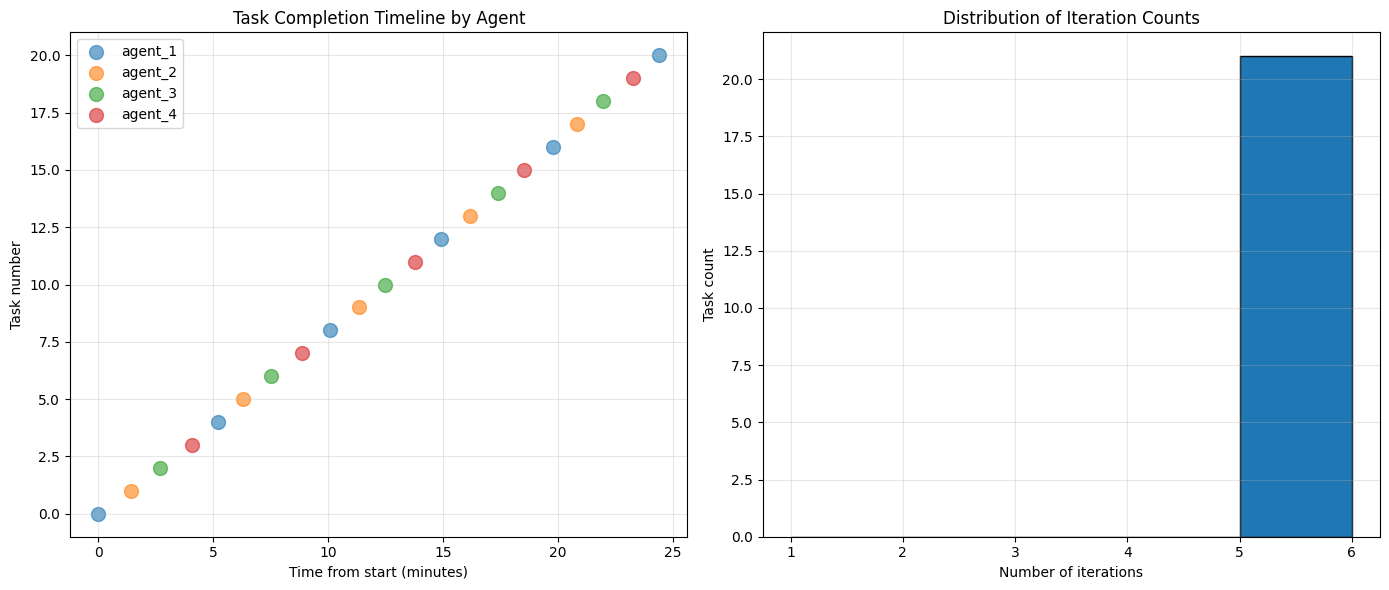

✅ Visualization saved to docs/reports/hybrid_execution_timeline.png


In [4]:
if not df.empty:
    plt.figure(figsize=(14, 6))
    
    # Task completions over time
    plt.subplot(1, 2, 1)
    for agent in df['agent'].unique():
        agent_data = df[df['agent'] == agent]
        plt.scatter(agent_data['time_from_start'], 
                   agent_data.index, 
                   label=agent, 
                   s=100, 
                   alpha=0.6)
    plt.xlabel('Time from start (minutes)')
    plt.ylabel('Task number')
    plt.title('Task Completion Timeline by Agent')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Iterations distribution
    plt.subplot(1, 2, 2)
    df['iterations'].hist(bins=range(1, df['iterations'].max()+2), edgecolor='black')
    plt.xlabel('Number of iterations')
    plt.ylabel('Task count')
    plt.title('Distribution of Iteration Counts')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../docs/reports/hybrid_execution_timeline.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Visualization saved to docs/reports/hybrid_execution_timeline.png")

## Claude API Call Analysis

In [5]:
# Parse Claude API calls
api_pattern = r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}),\d+ - httpx - INFO - HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"'

api_calls = []
for match in re.finditer(api_pattern, log_data):
    timestamp = datetime.strptime(match.group(1), '%Y-%m-%d %H:%M:%S')
    api_calls.append({'timestamp': timestamp})

api_df = pd.DataFrame(api_calls)

if not api_df.empty:
    api_df['time_from_start'] = (api_df['timestamp'] - api_df['timestamp'].min()).dt.total_seconds() / 60
    api_df['api_duration'] = api_df['time_from_start'].diff().fillna(0)
    
    print(f"📡 CLAUDE API METRICS")
    print(f"="*50)
    print(f"Total API calls: {len(api_df)}")
    print(f"Average time between calls: {api_df['api_duration'].mean()*60:.1f} seconds")
    print(f"Calls per completed task: {len(api_df)/len(df):.1f}")
    print(f"")
    print(f"Expected: ~5 calls per task (5 iterations max)")
    print(f"Actual: {len(api_df)/len(df):.1f} calls per task")

📡 CLAUDE API METRICS
Total API calls: 107
Average time between calls: 14.5 seconds
Calls per completed task: 5.1

Expected: ~5 calls per task (5 iterations max)
Actual: 5.1 calls per task


## Cost Analysis

In [6]:
if not df.empty:
    # Cost assumptions
    RUNPOD_COST_PER_HOUR = 0.60
    CLAUDE_COST_PER_TASK = 0.002  # Estimated based on token usage
    
    runpod_cost = (total_time / 60) * RUNPOD_COST_PER_HOUR
    claude_cost = len(api_df) * CLAUDE_COST_PER_TASK
    total_cost = runpod_cost + claude_cost
    cost_per_task = total_cost / len(df)
    
    # Compare to Claude-only
    claude_only_cost_per_task = 0.05  # Estimated
    savings = ((claude_only_cost_per_task - cost_per_task) / claude_only_cost_per_task) * 100
    
    print(f"💰 COST ANALYSIS")
    print(f"="*50)
    print(f"RunPod cost: ${runpod_cost:.3f} ({total_time:.1f} min @ ${RUNPOD_COST_PER_HOUR}/hr)")
    print(f"Claude API cost: ${claude_cost:.3f} ({len(api_df)} calls)")
    print(f"Total cost: ${total_cost:.3f}")
    print(f"Cost per task: ${cost_per_task:.4f}")
    print(f"")
    print(f"📊 COMPARISON")
    print(f"Claude-only cost/task: ${claude_only_cost_per_task:.4f}")
    print(f"Hybrid cost/task: ${cost_per_task:.4f}")
    print(f"Savings: {savings:.1f}%")

💰 COST ANALYSIS
RunPod cost: $0.244 (24.4 min @ $0.6/hr)
Claude API cost: $0.214 (107 calls)
Total cost: $0.458
Cost per task: $0.0218

📊 COMPARISON
Claude-only cost/task: $0.0500
Hybrid cost/task: $0.0218
Savings: 56.4%


## Task Details Table

In [7]:
if not df.empty:
    print("\n📋 COMPLETED TASKS")
    print("="*100)
    display_df = df[['timestamp', 'agent', 'task', 'iterations', 'status']].copy()
    display_df['timestamp'] = display_df['timestamp'].dt.strftime('%H:%M:%S')
    display(display_df)


📋 COMPLETED TASKS


,timestamp,agent,task,iterations,status
0,16:32:50,agent_1,github-synchronization/1,5,max_iterations
1,16:34:17,agent_2,observatory-social-authentication/* 1,5,max_iterations
2,16:35:31,agent_3,github-synchronization/2,5,max_iterations
3,16:36:56,agent_4,hybrid-code-generator/* 2,5,max_iterations
4,16:38:04,agent_1,github-synchronization/3,5,max_iterations
5,16:39:09,agent_2,hybrid-code-generator/* 3,5,max_iterations
6,16:40:22,agent_3,github-synchronization/4,5,max_iterations
7,16:41:41,agent_4,hybrid-code-generator/* 4,5,max_iterations
8,16:42:56,agent_1,github-synchronization/5,5,max_iterations
9,16:44:10,agent_2,github-synchronization/6,5,max_iterations


## Performance Summary

In [8]:
if not df.empty:
    print(f"""\n
    ╔═══════════════════════════════════════════════════════════╗
    ║     HYBRID CODE GENERATION PERFORMANCE SUMMARY           ║
    ╠═══════════════════════════════════════════════════════════╣
    ║                                                           ║
    ║  Total Tasks:        {len(df):>3}                                  ║
    ║  Execution Time:     {total_time:>5.1f} minutes                      ║
    ║  Tasks/Minute:       {tasks_per_minute:>5.2f}                            ║
    ║  Avg Iterations:     {avg_iterations:>5.1f}                            ║
    ║  Total Cost:         ${total_cost:>6.3f}                          ║
    ║  Cost/Task:          ${cost_per_task:>6.4f}                         ║
    ║  Cost Savings:       {savings:>5.1f}%                            ║
    ║                                                           ║
    ╚═══════════════════════════════════════════════════════════╝
    """)



    ╔═══════════════════════════════════════════════════════════╗
    ║     HYBRID CODE GENERATION PERFORMANCE SUMMARY           ║
    ╠═══════════════════════════════════════════════════════════╣
    ║                                                           ║
    ║  Total Tasks:         21                                  ║
    ║  Execution Time:      24.4 minutes                      ║
    ║  Tasks/Minute:        0.86                            ║
    ║  Avg Iterations:       5.0                            ║
    ║  Total Cost:         $ 0.458                          ║
    ║  Cost/Task:          $0.0218                         ║
    ║  Cost Savings:        56.4%                            ║
    ║                                                           ║
    ╚═══════════════════════════════════════════════════════════╝
    
